# Hamiltonian Dynamics and Symplectic Integrators

For a Hamiltonian $H(q,p)=\frac12 p^2 + V(q)$, equations of motion are
$$
\dot q = \partial_p H,\qquad \dot p = -\partial_q H.
$$
Symplectic schemes (like Störmer–Verlet) preserve geometric structure and usually control long-time energy drift better than explicit Euler.


## Environment

We load numerical tools and define a notebook-local output directory for generated figures.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

OUTPUT_DIR = Path("python/hamiltonian-symplectic") if Path("python/hamiltonian-symplectic").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Numerical Experiment

We implement the core algorithm and generate comparative visuals to expose behavior clearly.


/var/folders/c3/8qf_y_jj6393y3l0dl0bb3k80000gp/T/ipykernel_31165/660622495.py:9: RuntimeWarning: overflow encountered in scalar power
  return q + 0.4*q**3
/var/folders/c3/8qf_y_jj6393y3l0dl0bb3k80000gp/T/ipykernel_31165/660622495.py:19: RuntimeWarning: invalid value encountered in scalar subtract
  pe[k+1] = pe[k] - dt*dV(qe[k])
/var/folders/c3/8qf_y_jj6393y3l0dl0bb3k80000gp/T/ipykernel_31165/660622495.py:6: RuntimeWarning: overflow encountered in power
  return 0.5*q**2 + 0.1*q**4


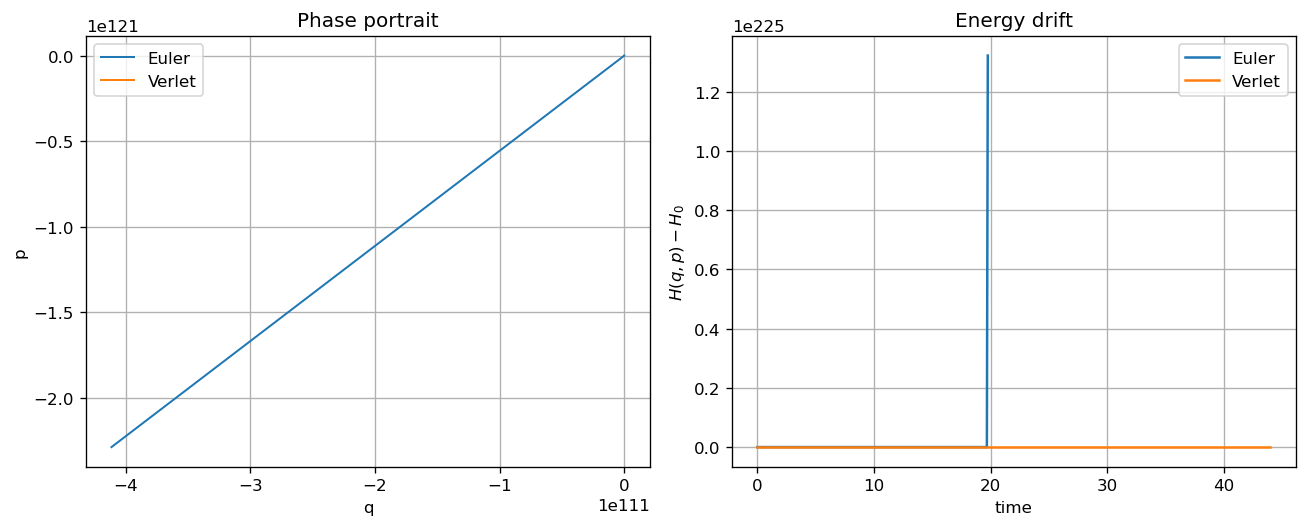

In [2]:
q0, p0 = 1.2, 0.0
dt = 0.08
n_steps = 550

def V(q):
    return 0.5*q**2 + 0.1*q**4

def dV(q):
    return q + 0.4*q**3

def energy(q, p):
    return 0.5*p**2 + V(q)

# explicit Euler
qe = np.zeros(n_steps+1); pe = np.zeros(n_steps+1)
qe[0], pe[0] = q0, p0
for k in range(n_steps):
    qe[k+1] = qe[k] + dt*pe[k]
    pe[k+1] = pe[k] - dt*dV(qe[k])

# Stormer-Verlet
qs = np.zeros(n_steps+1); ps = np.zeros(n_steps+1)
qs[0], ps[0] = q0, p0
for k in range(n_steps):
    p_half = ps[k] - 0.5*dt*dV(qs[k])
    qs[k+1] = qs[k] + dt*p_half
    ps[k+1] = p_half - 0.5*dt*dV(qs[k+1])

t = np.arange(n_steps+1)*dt
Ee = energy(qe, pe); Es = energy(qs, ps)
E0 = energy(q0, p0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(qe, pe, lw=1.2, label="Euler")
axes[0].plot(qs, ps, lw=1.2, label="Verlet")
axes[0].set_title("Phase portrait")
axes[0].set_xlabel("q"); axes[0].set_ylabel("p"); axes[0].legend()

axes[1].plot(t, Ee-E0, label="Euler")
axes[1].plot(t, Es-E0, label="Verlet")
axes[1].set_title("Energy drift")
axes[1].set_xlabel("time"); axes[1].set_ylabel(r"$H(q,p)-H_0$"); axes[1].legend()

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- J. Nocedal and S. Wright, *Numerical Optimization*.
- L. N. Trefethen, *Finite Difference and Spectral Methods* (lecture notes).
- D. P. Bertsekas, *Nonlinear Programming*.
